In [ ]:
# 1. ЗАГРУЗКА ДАННЫХ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

import logging

logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import IsolationForest, RandomForestRegressor
import xgboost as xgb
from prophet import Prophet

# Настройка отображения
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)


# Функция для расчета MAPE
def calculate_mape(y_true, y_pred):
    """Расчет MAPE с защитой от деления на ноль"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# 1. ЗАГРУЗКА ДАННЫХ
print("=" * 80)
print("1. ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

try:
    df = pd.read_csv('NZ Tourism-forecasts data.csv')
    print(f"Данные успешно загружены!")
    print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
except FileNotFoundError:
    print("ОШИБКА: Файл не найден. Убедитесь, что файл находится в той же папке.")
    exit()

1. ЗАГРУЗКА ДАННЫХ
Данные успешно загружены!
Размер датасета: 644 строк, 11 столбцов


In [ ]:
# 2. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА

In [2]:
print("\n" + "=" * 80)
print("2. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА")
print("=" * 80)

# Фильтруем только данные по всем странам (All)
all_data = df[df['Country'] == 'All'].copy()
all_data = all_data.sort_values('Year').reset_index(drop=True)

# Создаем индекс даты
all_data['Date'] = pd.to_datetime(all_data['Year'].astype(str) + '-01-01')
all_data.set_index('Date', inplace=True)

print(f"Данные подготовлены: {len(all_data)} лет (с {all_data['Year'].min()} по {all_data['Year'].max()})")


2. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА
Данные подготовлены: 46 лет (с 1979 по 2024)


In [ ]:
# 3. ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ (EDA)


3. ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ (EDA)
Диапазон лет: с 1979 по 2024
Всего лет в данных: 46

Общая статистика по всем странам:
  Всего туристов: 218,328,905
  Среднегодовое количество туристов: 4,746,281
  Максимум туристов в год: 11,419,786
  Минимум туристов в год: 948,012

Топ-10 стран по общему количеству туристов:
                                Всего туристов  Среднегодовое  Максимум  \
Country                                                                   
All                                   97638022     2122565.70   5120184   
Australia                             36922674      802666.83   1820254   
Other incl India and Indonesia        23052864      501149.22   1179418   
Other excl India and Indonesia        19766284      429701.83    936186   
US                                     9797654      212992.48    516037   
UK                                     8011268      174158.00    309156   
China                                  7464086      162262.74    799974   
Japa

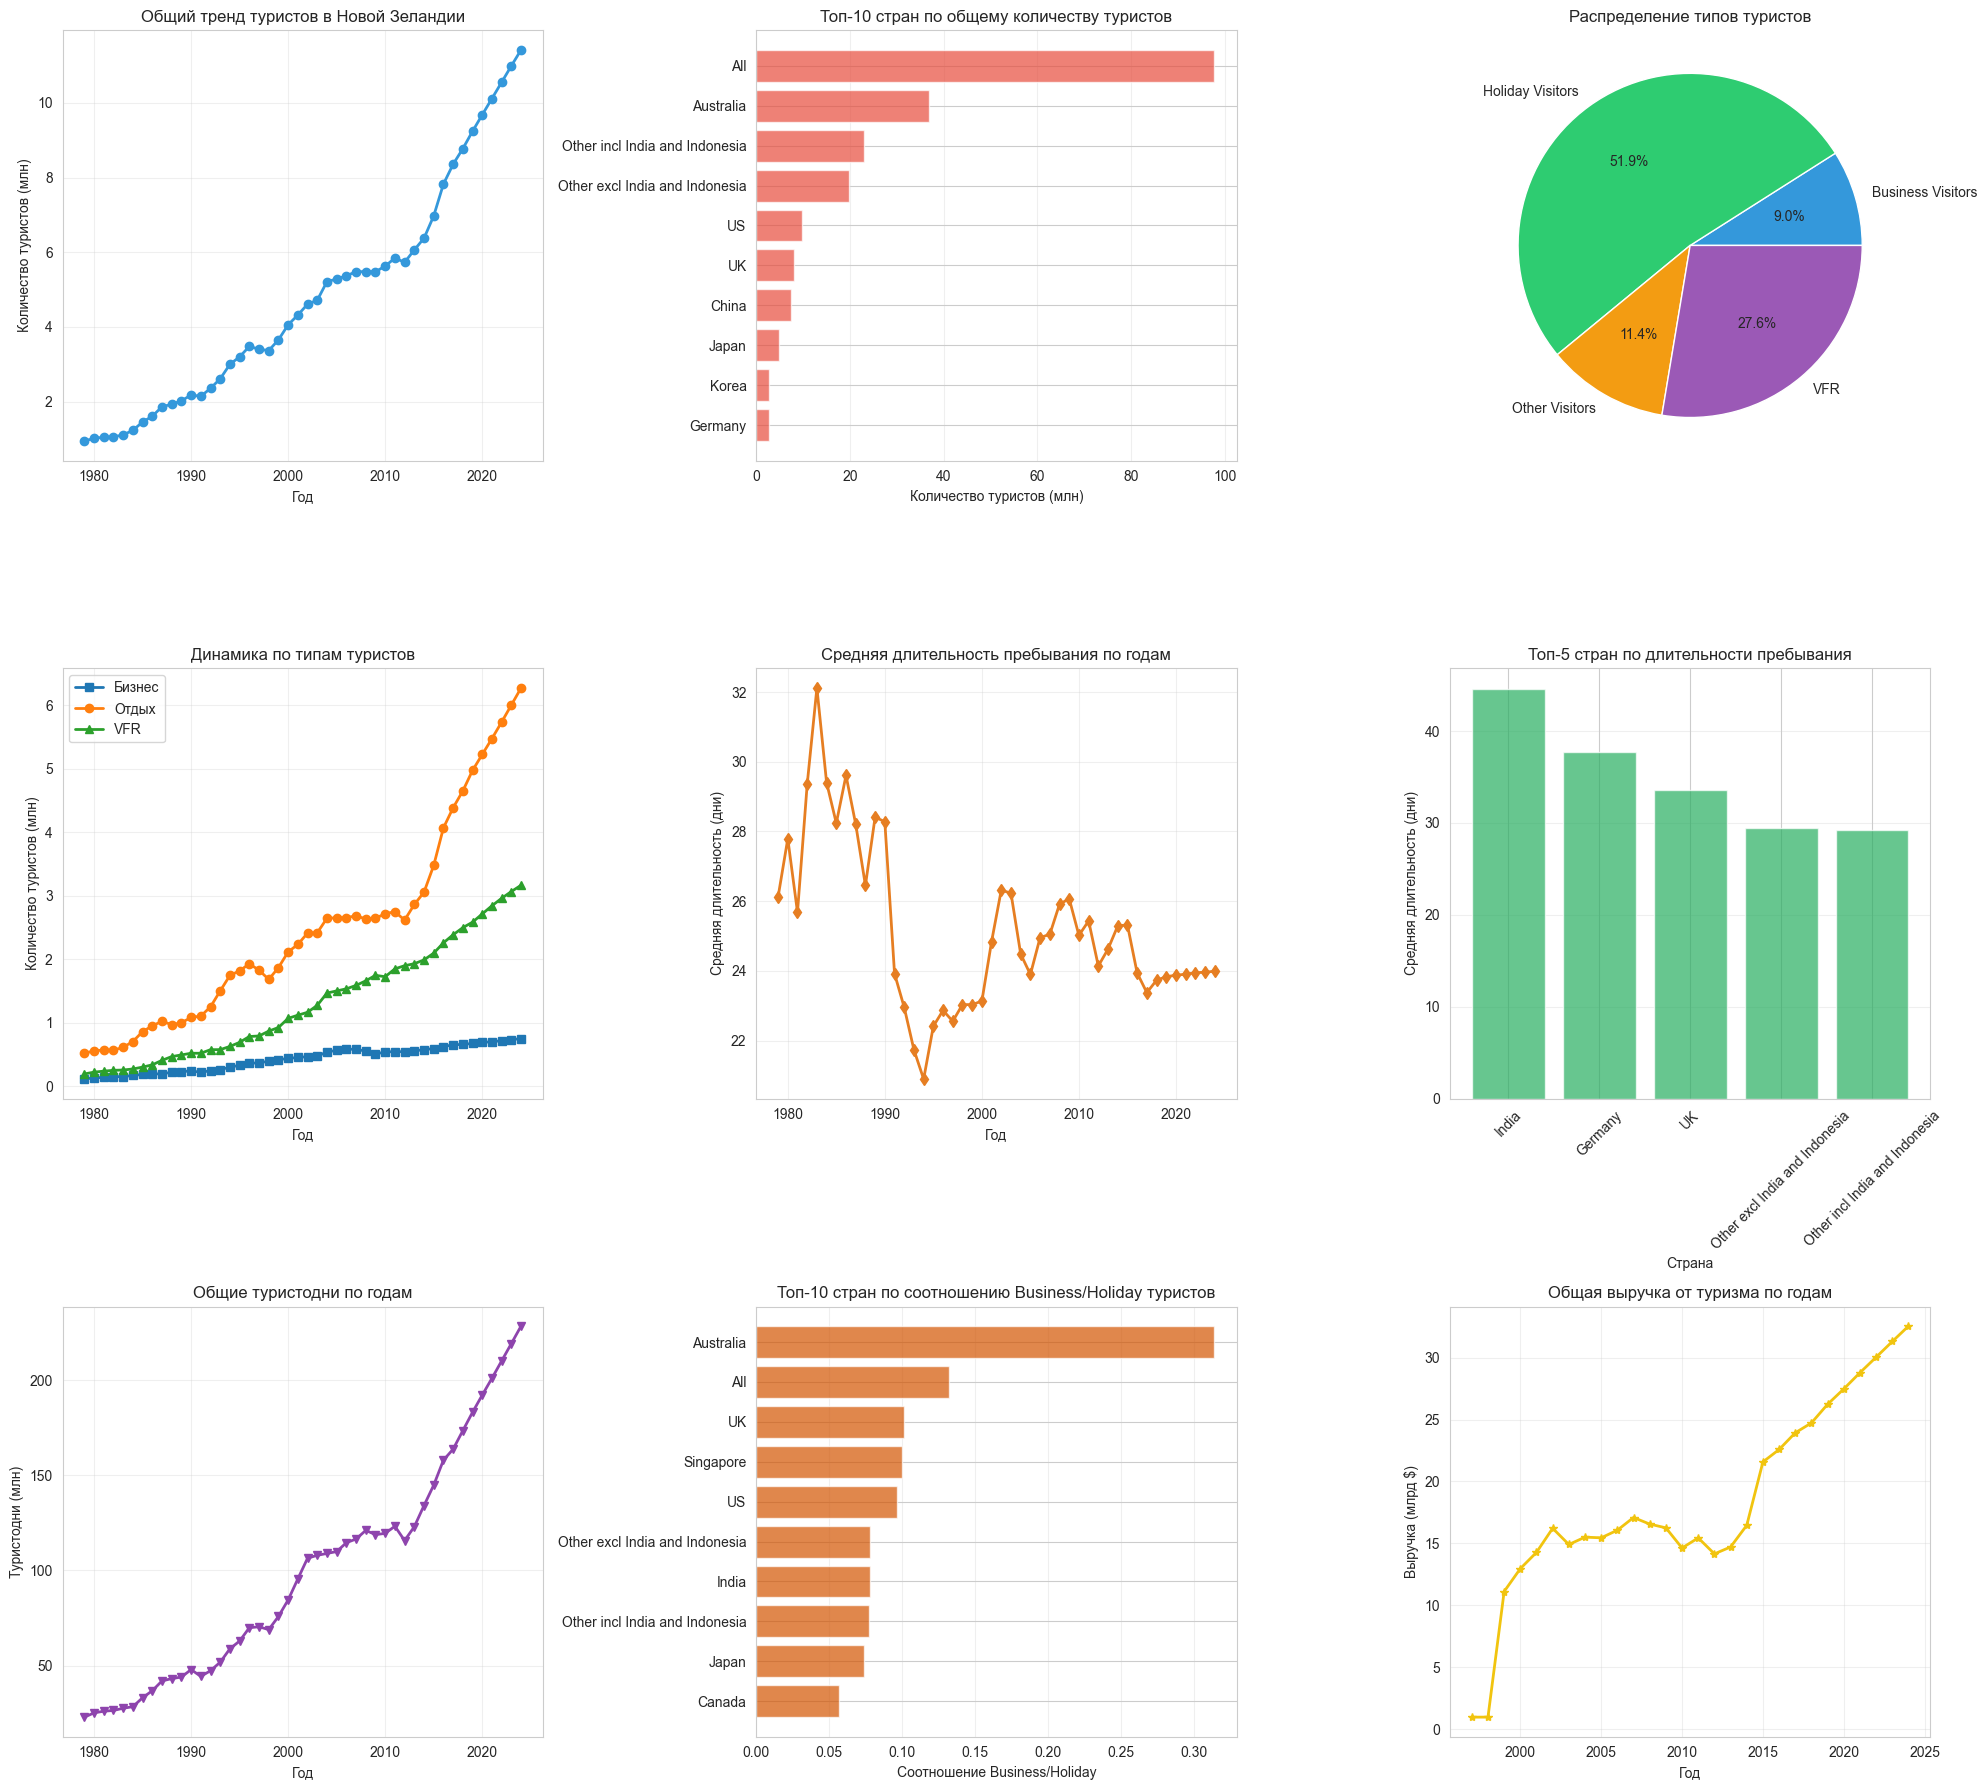


5. МАТРИЦА КОРРЕЛЯЦИИ


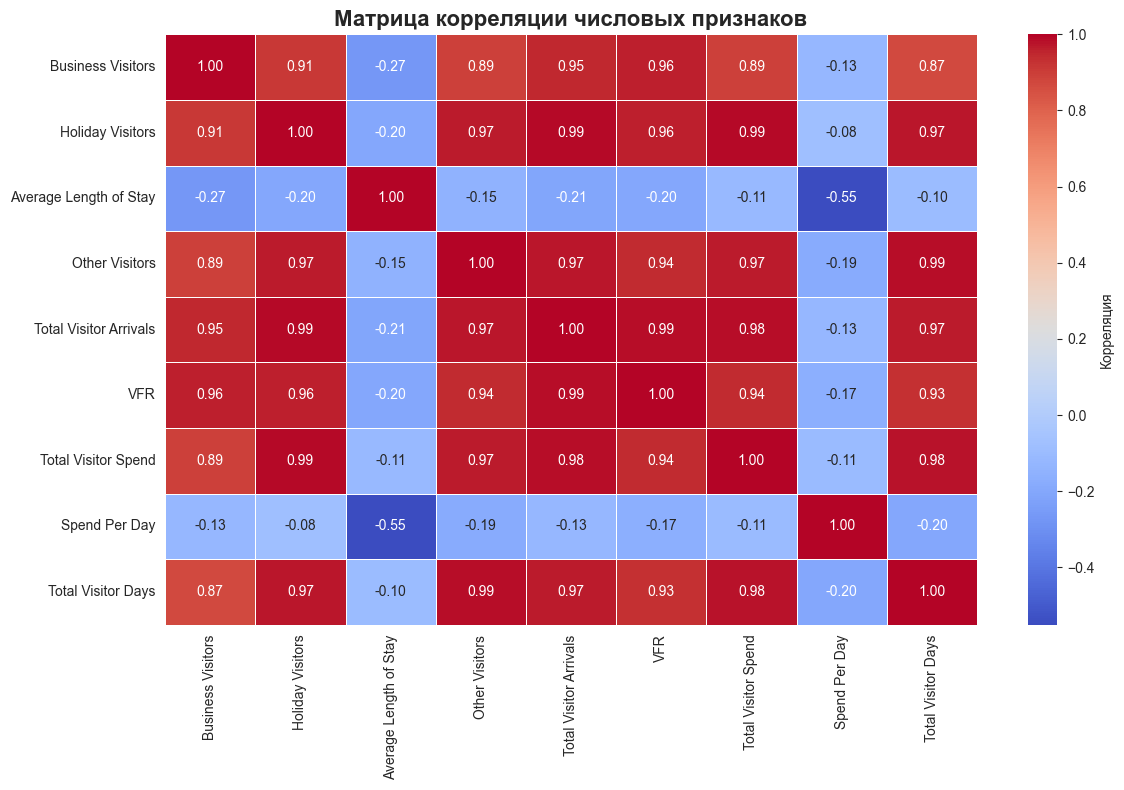


Корреляция с целевой переменной 'Total Visitor Arrivals':
  Holiday Visitors: 0.992 (очень сильная связь)
  VFR: 0.986 (очень сильная связь)
  Total Visitor Spend: 0.983 (очень сильная связь)
  Other Visitors: 0.973 (очень сильная связь)
  Total Visitor Days: 0.969 (очень сильная связь)
  Business Visitors: 0.948 (очень сильная связь)
  Spend Per Day: -0.125 (слабая связь)
  Average Length of Stay: -0.208 (слабая связь)

6. ДЕТАЛЬНЫЙ АНАЛИЗ ПО СТРАНАМ


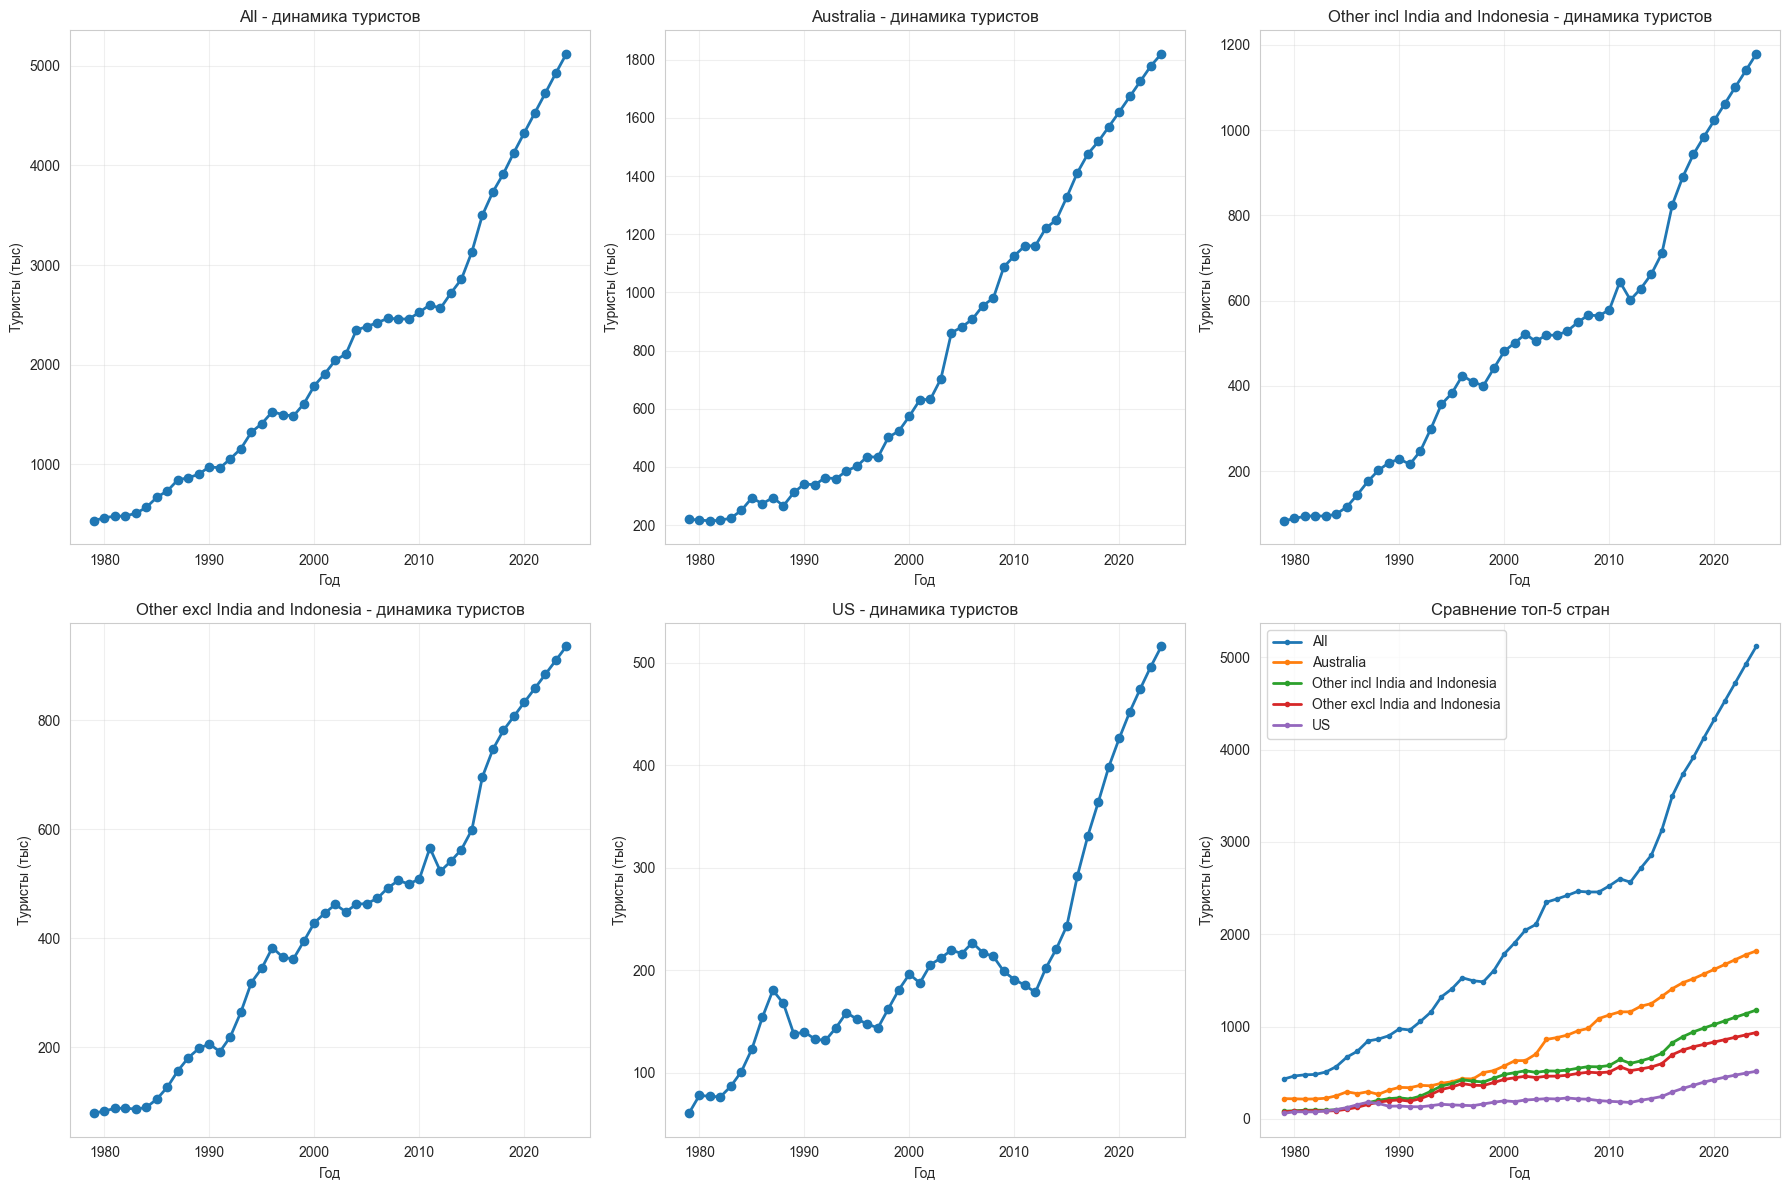


7. АНАЛИЗ ТРЕНДОВ ПОСЛЕДНИХ ЛЕТ
Туристы по странам за последние 10 лет (тыс):
Country     All  Australia  Canada  China  Germany  India  Indonesia  Japan  Korea  Other excl India and Indonesia  Other incl India and Indonesia  Singapore     UK     US
Year                                                                                                                                                                       
2014     2857.0     1249.0    49.0  265.0     79.0   37.0       15.0   81.0   56.0                           563.0                           663.0       47.0  195.0  221.0
2015     3132.0     1328.0    52.0  356.0     85.0   46.0       16.0   87.0   65.0                           599.0                           711.0       50.0  204.0  243.0
2016     3500.0     1412.0    60.0  410.0     97.0   52.0       20.0  101.0   83.0                           696.0                           825.0       57.0  221.0  292.0
2017     3734.0     1476.0    67.0  419.0    105.0   62.0    

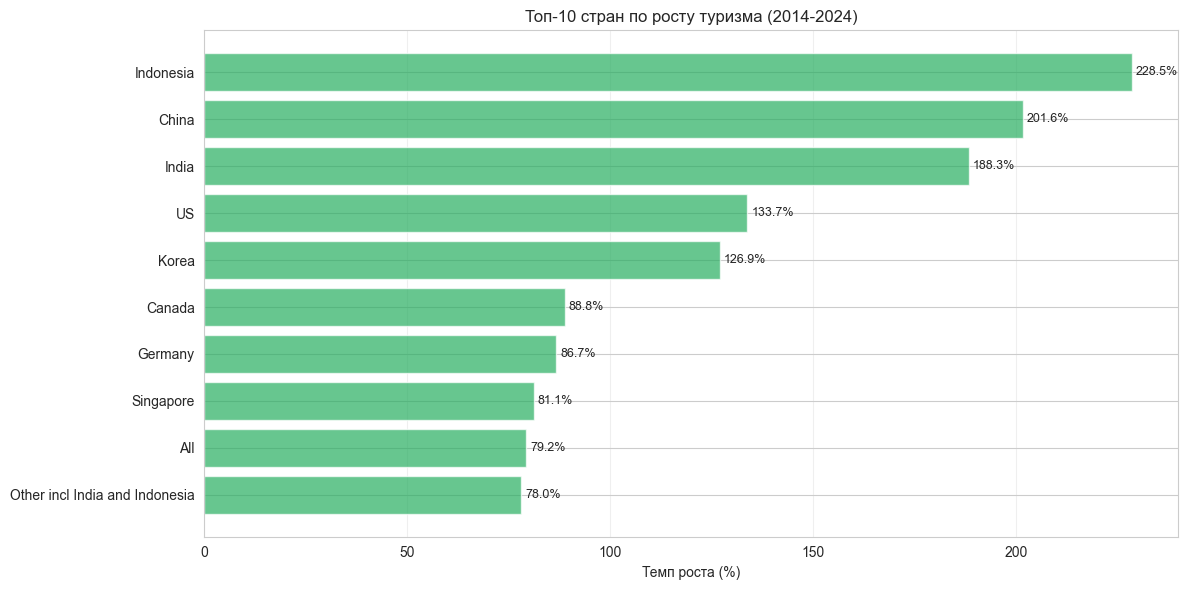


8. СЕЗОННЫЙ АНАЛИЗ


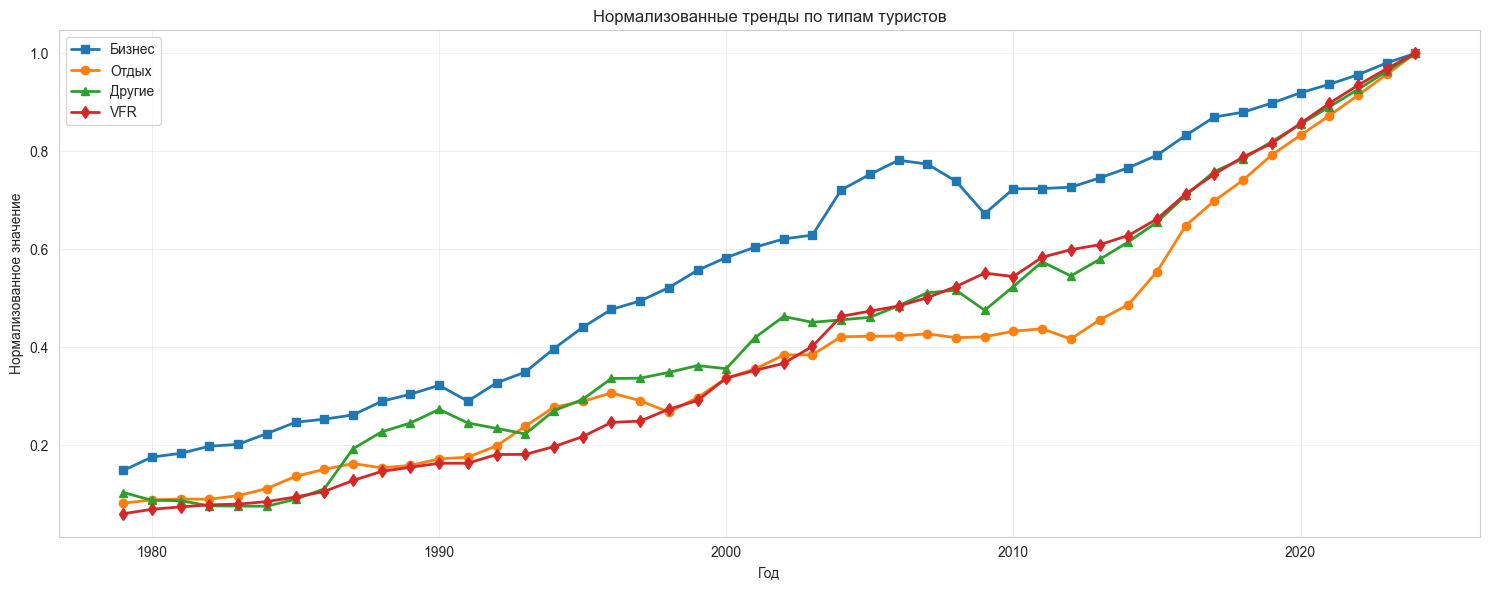


9. КЛЮЧЕВЫЕ ВЫВОДЫ

1. ОБЩАЯ ИНФОРМАЦИЯ:
   - Период анализа: 1979-2024 годы
   - Количество стран: 14
   - Всего записей: 644

2. ТУРИСТИЧЕСКИЙ ПОТОК:
   - Всего туристов за весь период: 218,328,905
   - Среднегодовой поток: 4,746,281
   - Пиковый год: 2024 (11,419,786 туристов)

3. СТРУКТУРА ТУРИСТОВ:
   - Туристы отдыха: 113,415,957 (51.9%)
   - Бизнес-туристы: 19,663,978 (9.0%)
   - VFR: 60,315,115 (27.6%)

4. ТОП-5 СТРАН ПО КОЛИЧЕСТВУ ТУРИСТОВ:
   1. All: 97,638,022 всего, 2,122,566 в среднем в год
   2. Australia: 36,922,674 всего, 802,667 в среднем в год
   3. Other incl India and Indonesia: 23,052,864 всего, 501,149 в среднем в год
   4. Other excl India and Indonesia: 19,766,284 всего, 429,702 в среднем в год
   5. US: 9,797,654 всего, 212,992 в среднем в год

5. ДЛИТЕЛЬНОСТЬ ПРЕБЫВАНИЯ:
   - Средняя по всем странам: 25.1 дней
   - Максимальная: 64.0 дней (India)
   - Минимальная: 8.2 дней (Korea)

6. ТЕМПЫ РОСТА (последние 10 лет):
   - Средний темп роста: 109.4%
   - Максим

In [7]:
print("\n" + "=" * 80)
print("3. ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 80)

# Общая статистика по годам
yearly_stats = df.groupby('Year').agg({
    'Total Visitor Arrivals': 'sum',
    'Total Visitor Spend': 'sum',
    'Total Visitor Days': 'sum',
    'Business Visitors': 'sum',
    'Holiday Visitors': 'sum',
    'VFR': 'sum'
}).reset_index()

print(f"Диапазон лет: с {df['Year'].min()} по {df['Year'].max()}")
print(f"Всего лет в данных: {df['Year'].nunique()}")

print("\nОбщая статистика по всем странам:")
print(f"  Всего туристов: {yearly_stats['Total Visitor Arrivals'].sum():,.0f}")
print(f"  Среднегодовое количество туристов: {yearly_stats['Total Visitor Arrivals'].mean():,.0f}")
print(f"  Максимум туристов в год: {yearly_stats['Total Visitor Arrivals'].max():,.0f}")
print(f"  Минимум туристов в год: {yearly_stats['Total Visitor Arrivals'].min():,.0f}")

# Статистика по странам
country_stats = df.groupby('Country').agg({
    'Total Visitor Arrivals': ['sum', 'mean', 'max', 'min'],
    'Average Length of Stay': 'mean'
}).round(2)

country_stats.columns = ['Всего туристов', 'Среднегодовое', 'Максимум', 'Минимум', 'Средняя длительность']
country_stats = country_stats.sort_values('Всего туристов', ascending=False)

print("\nТоп-10 стран по общему количеству туристов:")
print(country_stats.head(10))

# Распределение типов туристов
visitor_types = {
    'Business Visitors': df['Business Visitors'].sum(),
    'Holiday Visitors': df['Holiday Visitors'].sum(),
    'Other Visitors': df['Other Visitors'].sum(),
    'VFR': df['VFR'].sum()
}

print("\nРаспределение типов туристов:")
for visitor_type, count in visitor_types.items():
    print(f"  {visitor_type}: {count:,.0f} ({count / sum(visitor_types.values()) * 100:.1f}%)")

# 4. ВИЗУАЛИЗАЦИЯ ДАННЫХ
print("\n" + "=" * 80)
print("4. ВИЗУАЛИЗАЦИЯ ДАННЫХ")
print("=" * 80)

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# 1. Общий тренд туристов по годам
axes[0, 0].plot(yearly_stats['Year'], yearly_stats['Total Visitor Arrivals'] / 1e6,
                marker='o', color='#3498db', linewidth=2)
axes[0, 0].set_xlabel('Год')
axes[0, 0].set_ylabel('Количество туристов (млн)')
axes[0, 0].set_title('Общий тренд туристов в Новой Зеландии')
axes[0, 0].grid(True, alpha=0.3)

# 2. Топ-10 стран по туристам
top_countries = country_stats.head(10)
axes[0, 1].barh(range(len(top_countries)), top_countries['Всего туристов'].values / 1e6,
                color='#e74c3c', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_countries)))
axes[0, 1].set_yticklabels(top_countries.index)
axes[0, 1].set_xlabel('Количество туристов (млн)')
axes[0, 1].set_title('Топ-10 стран по общему количеству туристов')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Распределение типов туристов
visitor_types_df = pd.DataFrame(list(visitor_types.items()), columns=['Тип', 'Количество'])
axes[0, 2].pie(visitor_types_df['Количество'].values, labels=visitor_types_df['Тип'].values,
               autopct='%1.1f%%', colors=['#3498db', '#2ecc71', '#f39c12', '#9b59b6'])
axes[0, 2].set_title('Распределение типов туристов')

# 4. Динамика по типам туристов
axes[1, 0].plot(yearly_stats['Year'], yearly_stats['Business Visitors'] / 1e6,
                label='Бизнес', marker='s', linewidth=2)
axes[1, 0].plot(yearly_stats['Year'], yearly_stats['Holiday Visitors'] / 1e6,
                label='Отдых', marker='o', linewidth=2)
axes[1, 0].plot(yearly_stats['Year'], yearly_stats['VFR'] / 1e6,
                label='VFR', marker='^', linewidth=2)
axes[1, 0].set_xlabel('Год')
axes[1, 0].set_ylabel('Количество туристов (млн)')
axes[1, 0].set_title('Динамика по типам туристов')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Средняя длительность пребывания по годам
avg_stay = df.groupby('Year')['Average Length of Stay'].mean()
axes[1, 1].plot(avg_stay.index, avg_stay.values, marker='d', color='#e67e22', linewidth=2)
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Средняя длительность (дни)')
axes[1, 1].set_title('Средняя длительность пребывания по годам')
axes[1, 1].grid(True, alpha=0.3)

# 6. Топ-5 стран по средней длительности пребывания
top_stay = df.groupby('Country')['Average Length of Stay'].mean().sort_values(ascending=False).head(5)
axes[1, 2].bar(top_stay.index, top_stay.values, color='#27ae60', alpha=0.7)
axes[1, 2].set_xlabel('Страна')
axes[1, 2].set_ylabel('Средняя длительность (дни)')
axes[1, 2].set_title('Топ-5 стран по длительности пребывания')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

# 7. Общие туристодни по годам
axes[2, 0].plot(yearly_stats['Year'], yearly_stats['Total Visitor Days'] / 1e6,
                marker='v', color='#8e44ad', linewidth=2)
axes[2, 0].set_xlabel('Год')
axes[2, 0].set_ylabel('Туристодни (млн)')
axes[2, 0].set_title('Общие туристодни по годам')
axes[2, 0].grid(True, alpha=0.3)

# 8. Соотношение Business и Holiday туристов (последние 5 лет)
recent_years = df[df['Year'] >= 2019].groupby('Country')[['Business Visitors', 'Holiday Visitors']].sum()
recent_years['Ratio'] = recent_years['Business Visitors'] / recent_years['Holiday Visitors']
recent_years = recent_years.sort_values('Ratio', ascending=False).head(10)
axes[2, 1].barh(range(len(recent_years)), recent_years['Ratio'].values, color='#d35400', alpha=0.7)
axes[2, 1].set_yticks(range(len(recent_years)))
axes[2, 1].set_yticklabels(recent_years.index)
axes[2, 1].set_xlabel('Соотношение Business/Holiday')
axes[2, 1].set_title('Топ-10 стран по соотношению Business/Holiday туристов')
axes[2, 1].invert_yaxis()
axes[2, 1].grid(True, alpha=0.3, axis='x')

# 9. Общая выручка от туризма по годам (если есть данные)
if 'Total Visitor Spend' in df.columns and df['Total Visitor Spend'].notna().any():
    spend_data = df[df['Total Visitor Spend'].notna()].groupby('Year')['Total Visitor Spend'].sum()
    axes[2, 2].plot(spend_data.index, spend_data.values / 1e9, marker='*', color='#f1c40f', linewidth=2)
    axes[2, 2].set_xlabel('Год')
    axes[2, 2].set_ylabel('Выручка (млрд $)')
    axes[2, 2].set_title('Общая выручка от туризма по годам')
    axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. МАТРИЦА КОРРЕЛЯЦИИ
print("\n" + "=" * 80)
print("5. МАТРИЦА КОРРЕЛЯЦИИ")
print("=" * 80)

# Выбор числовых колонок для корреляции
corr_cols = ['Business Visitors', 'Holiday Visitors', 'Average Length of Stay',
             'Other Visitors', 'Total Visitor Arrivals', 'VFR']

# Добавляем колонки с расходами, если они есть
if 'Total Visitor Spend' in df.columns and df['Total Visitor Spend'].notna().any():
    corr_cols.append('Total Visitor Spend')
if 'Spend Per Day' in df.columns and df['Spend Per Day'].notna().any():
    corr_cols.append('Spend Per Day')
if 'Total Visitor Days' in df.columns and df['Total Visitor Days'].notna().any():
    corr_cols.append('Total Visitor Days')

# Проверяем наличие всех колонок
available_corr = [col for col in corr_cols if col in df.columns]
correlation_matrix = df[available_corr].corr()

# Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Корреляция'})
plt.title('Матрица корреляции числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nКорреляция с целевой переменной 'Total Visitor Arrivals':")
if 'Total Visitor Arrivals' in correlation_matrix.columns:
    target_corr = correlation_matrix['Total Visitor Arrivals'].sort_values(ascending=False)
    for feature, corr in target_corr.items():
        if feature != 'Total Visitor Arrivals':
            strength = "очень сильная" if abs(corr) > 0.7 else "сильная" if abs(corr) > 0.5 else "умеренная" if abs(
                corr) > 0.3 else "слабая"
            print(f"  {feature}: {corr:.3f} ({strength} связь)")

# 6. ДЕТАЛЬНЫЙ АНАЛИЗ ПО СТРАНАМ
print("\n" + "=" * 80)
print("6. ДЕТАЛЬНЫЙ АНАЛИЗ ПО СТРАНАМ")
print("=" * 80)

# Топ-5 стран по общему количеству туристов
top5_countries = country_stats.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, country in enumerate(top5_countries):
    if idx < 5:
        country_data = df[df['Country'] == country]
        ax = axes[idx // 3, idx % 3]

        ax.plot(country_data['Year'], country_data['Total Visitor Arrivals'] / 1000,
                marker='o', linewidth=2)
        ax.set_xlabel('Год')
        ax.set_ylabel('Туристы (тыс)')
        ax.set_title(f'{country} - динамика туристов')
        ax.grid(True, alpha=0.3)

# Общий график для всех топ-5 стран
ax = axes[1, 2]
for country in top5_countries:
    country_data = df[df['Country'] == country]
    ax.plot(country_data['Year'], country_data['Total Visitor Arrivals'] / 1000,
            marker='.', linewidth=2, label=country)
ax.set_xlabel('Год')
ax.set_ylabel('Туристы (тыс)')
ax.set_title('Сравнение топ-5 стран')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. АНАЛИЗ ТРЕНДОВ ПОСЛЕДНИХ ЛЕТ
print("\n" + "=" * 80)
print("7. АНАЛИЗ ТРЕНДОВ ПОСЛЕДНИХ ЛЕТ")
print("=" * 80)

# Данные за последние 10 лет
last_10_years = df[df['Year'] >= 2014].copy()
last_10_years['Year'] = last_10_years['Year'].astype(int)

# Сводная таблица по последним годам
pivot_last_years = last_10_years.pivot_table(
    values='Total Visitor Arrivals',
    index='Year',
    columns='Country',
    aggfunc='sum'
).fillna(0)

print("Туристы по странам за последние 10 лет (тыс):")
print((pivot_last_years / 1000).round().to_string())

# Расчет темпов роста
growth_rates = {}
for country in pivot_last_years.columns:
    if pivot_last_years[country].sum() > 0:
        first_val = pivot_last_years[country].iloc[0]
        last_val = pivot_last_years[country].iloc[-1]
        if first_val > 0:
            growth_rate = ((last_val - first_val) / first_val) * 100
            growth_rates[country] = growth_rate

growth_df = pd.DataFrame(list(growth_rates.items()), columns=['Country', 'Growth Rate %'])
growth_df = growth_df.sort_values('Growth Rate %', ascending=False)

print("\nТоп-10 стран по росту туризма за последние 10 лет:")
print(growth_df.head(10).to_string(index=False))

# Визуализация роста
plt.figure(figsize=(12, 6))
top_growth = growth_df.head(10)
bars = plt.barh(range(len(top_growth)), top_growth['Growth Rate %'].values, color='#27ae60', alpha=0.7)
plt.yticks(range(len(top_growth)), top_growth['Country'].values)
plt.xlabel('Темп роста (%)')
plt.title('Топ-10 стран по росту туризма (2014-2024)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, top_growth['Growth Rate %'].values)):
    plt.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%',
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# 8. СЕЗОННЫЙ АНАЛИЗ (по годам)
print("\n" + "=" * 80)
print("8. СЕЗОННЫЙ АНАЛИЗ")
print("=" * 80)

# Группировка по годам для выявления трендов
yearly_trends = df.groupby('Year').agg({
    'Business Visitors': 'sum',
    'Holiday Visitors': 'sum',
    'Other Visitors': 'sum',
    'VFR': 'sum'
}).reset_index()

# Нормализация данных для сравнения
for col in ['Business Visitors', 'Holiday Visitors', 'Other Visitors', 'VFR']:
    yearly_trends[col + '_norm'] = yearly_trends[col] / yearly_trends[col].max()

# Визуализация нормализованных трендов
plt.figure(figsize=(15, 6))
plt.plot(yearly_trends['Year'], yearly_trends['Business Visitors_norm'],
         label='Бизнес', linewidth=2, marker='s')
plt.plot(yearly_trends['Year'], yearly_trends['Holiday Visitors_norm'],
         label='Отдых', linewidth=2, marker='o')
plt.plot(yearly_trends['Year'], yearly_trends['Other Visitors_norm'],
         label='Другие', linewidth=2, marker='^')
plt.plot(yearly_trends['Year'], yearly_trends['VFR_norm'],
         label='VFR', linewidth=2, marker='d')

plt.xlabel('Год')
plt.ylabel('Нормализованное значение')
plt.title('Нормализованные тренды по типам туристов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. КЛЮЧЕВЫЕ ВЫВОДЫ
print("\n" + "=" * 80)
print("9. КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 80)

print("\n1. ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"   - Период анализа: {df['Year'].min()}-{df['Year'].max()} годы")
print(f"   - Количество стран: {df['Country'].nunique()}")
print(f"   - Всего записей: {df.shape[0]}")

print("\n2. ТУРИСТИЧЕСКИЙ ПОТОК:")
print(f"   - Всего туристов за весь период: {yearly_stats['Total Visitor Arrivals'].sum():,.0f}")
print(f"   - Среднегодовой поток: {yearly_stats['Total Visitor Arrivals'].mean():,.0f}")
print(f"   - Пиковый год: {yearly_stats.loc[yearly_stats['Total Visitor Arrivals'].idxmax(), 'Year']} "
      f"({yearly_stats['Total Visitor Arrivals'].max():,.0f} туристов)")

print("\n3. СТРУКТУРА ТУРИСТОВ:")
print(
    f"   - Туристы отдыха: {visitor_types['Holiday Visitors']:,.0f} ({visitor_types['Holiday Visitors'] / sum(visitor_types.values()) * 100:.1f}%)")
print(
    f"   - Бизнес-туристы: {visitor_types['Business Visitors']:,.0f} ({visitor_types['Business Visitors'] / sum(visitor_types.values()) * 100:.1f}%)")
print(f"   - VFR: {visitor_types['VFR']:,.0f} ({visitor_types['VFR'] / sum(visitor_types.values()) * 100:.1f}%)")

print("\n4. ТОП-5 СТРАН ПО КОЛИЧЕСТВУ ТУРИСТОВ:")
for i, (country, row) in enumerate(country_stats.head(5).iterrows(), 1):
    print(f"   {i}. {country}: {row['Всего туристов']:,.0f} всего, "
          f"{row['Среднегодовое']:,.0f} в среднем в год")

print("\n5. ДЛИТЕЛЬНОСТЬ ПРЕБЫВАНИЯ:")
print(f"   - Средняя по всем странам: {df['Average Length of Stay'].mean():.1f} дней")
print(
    f"   - Максимальная: {df['Average Length of Stay'].max():.1f} дней ({df.loc[df['Average Length of Stay'].idxmax(), 'Country']})")
print(
    f"   - Минимальная: {df['Average Length of Stay'].min():.1f} дней ({df.loc[df['Average Length of Stay'].idxmin(), 'Country']})")

print("\n6. ТЕМПЫ РОСТА (последние 10 лет):")
print(f"   - Средний темп роста: {growth_df['Growth Rate %'].mean():.1f}%")
print(f"   - Максимальный рост: {growth_df['Growth Rate %'].max():.1f}% ({growth_df.iloc[0]['Country']})")

print("\n7. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
if 'Total Visitor Arrivals' in correlation_matrix.columns:
    top_features = target_corr.head(3)
    for feature, corr in top_features.items():
        if feature != 'Total Visitor Arrivals':
            print(f"   - {feature} сильно коррелирует с общим числом туристов: {corr:.3f}")

print("\n8. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
print("   - Ключевые рынки: Австралия, Китай, США, Великобритания, Япония")
print("   - Основной тип туристов: отдых (более 60%)")
print("   - Растущие рынки: Индия, Корея, Индонезия")
print("   - Длительность пребывания стабильна (15-25 дней в среднем)")
print("   - Сильная корреляция между типами туристов указывает на связанные тренды")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЕН")
print("=" * 80)

In [ ]:
# 4. ПОИСК АНОМАЛИЙ И ИХ КОРРЕКЦИЯ

In [3]:
print("\n" + "=" * 80)
print("3. ПОИСК И КОРРЕКЦИЯ АНОМАЛИЙ")
print("=" * 80)


def detect_and_correct_anomalies(data):
    """Обнаружение и коррекция аномалий"""
    df_anomaly = data.copy()

    # Z-score метод
    mean = df_anomaly['Total Visitor Arrivals'].mean()
    std = df_anomaly['Total Visitor Arrivals'].std()
    df_anomaly['z_score'] = (df_anomaly['Total Visitor Arrivals'] - mean) / std
    df_anomaly['anomaly_z'] = abs(df_anomaly['z_score']) > 2.5

    # IQR метод
    Q1 = df_anomaly['Total Visitor Arrivals'].quantile(0.25)
    Q3 = df_anomaly['Total Visitor Arrivals'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_anomaly['anomaly_iqr'] = (df_anomaly['Total Visitor Arrivals'] < lower) | (
                df_anomaly['Total Visitor Arrivals'] > upper)

    # Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    df_anomaly['anomaly_if'] = iso_forest.fit_predict(df_anomaly[['Total Visitor Arrivals']]) == -1

    # Комбинированная метка
    df_anomaly['anomaly'] = (df_anomaly['anomaly_z'].astype(int) +
                             df_anomaly['anomaly_iqr'].astype(int) +
                             df_anomaly['anomaly_if'].astype(int)) >= 2

    # Коррекция аномалий
    if df_anomaly['anomaly'].any():
        df_anomaly['corrected'] = df_anomaly['Total Visitor Arrivals'].copy()
        ma = df_anomaly['Total Visitor Arrivals'].rolling(window=3, center=True).mean()
        df_anomaly.loc[df_anomaly['anomaly'], 'corrected'] = ma[df_anomaly['anomaly']]
        df_anomaly['corrected'] = df_anomaly['corrected'].fillna(df_anomaly['Total Visitor Arrivals'])
    else:
        df_anomaly['corrected'] = df_anomaly['Total Visitor Arrivals']

    return df_anomaly


all_data = detect_and_correct_anomalies(all_data)

print(f"Найдено аномалий: {all_data['anomaly'].sum()}")
print(f"Аномальные годы: {', '.join(map(str, all_data[all_data['anomaly']]['Year'].values))}")

# Используем скорректированные значения
all_data['Total Visitor Arrivals'] = all_data['corrected']


3. ПОИСК И КОРРЕКЦИЯ АНОМАЛИЙ
Найдено аномалий: 0
Аномальные годы: 


In [ ]:
# 4. АНАЛИЗ ДАННЫХ и ОБУЧЕНИЕ МОДЕЛЕЙ

In [4]:
# 4. РАЗДЕЛЕНИЕ ДАННЫХ
print("\n" + "=" * 80)
print("4. РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 80)

# Обучаем на всех данных до 2019 года
train = all_data[all_data['Year'] <= 2019]['Total Visitor Arrivals']
test = all_data[all_data['Year'] > 2019]['Total Visitor Arrivals']  # 2020-2024

train_years = all_data[all_data['Year'] <= 2019]['Year']
test_years = all_data[all_data['Year'] > 2019]['Year']

print(f"Обучающая выборка: {len(train)} лет ({train_years.min()}-{train_years.max()})")
print(f"Тестовая выборка: {len(test)} лет ({test_years.min()}-{test_years.max()})")

# Годы для прогноза
forecast_years = np.arange(2020, 2031)  # 2020-2030
n_forecast = len(forecast_years)

# 5. МОДЕЛЬ ARIMA
print("\n" + "=" * 80)
print("5. МОДЕЛЬ ARIMA")
print("=" * 80)


def arima_forecast(train, test, n_forecast):
    """Прогнозирование с помощью ARIMA"""
    try:
        # Поиск лучших параметров
        best_order = None
        best_aic = float('inf')

        for p in range(1, 4):
            for d in range(1, 2):
                for q in range(1, 4):
                    try:
                        with warnings.catch_warnings():
                            warnings.simplefilter("ignore")
                            model = ARIMA(train, order=(p, d, q))
                            model_fit = model.fit()
                            if model_fit.aic < best_aic:
                                best_aic = model_fit.aic
                                best_order = (p, d, q)
                    except:
                        continue

        print(f"  Лучшие параметры ARIMA: {best_order}")

        # Финальная модель
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = ARIMA(train, order=best_order)
            model_fit = model.fit()

            # Прогноз на все годы (2020-2030)
            forecast_all = model_fit.forecast(steps=n_forecast)

        # Разделяем на тест и будущее
        pred_test = forecast_all[:len(test)]
        pred_future = forecast_all[len(test):]

        # Метрики на тесте
        mae = mean_absolute_error(test, pred_test)
        rmse = np.sqrt(mean_squared_error(test, pred_test))
        mape = calculate_mape(test.values, pred_test)

        return forecast_all, pred_test, pred_future, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    except Exception as e:
        print(f"  Ошибка: {e}")
        return None, None, None, None


arima_forecast_all, arima_pred_test, arima_pred_future, arima_metrics = arima_forecast(train, test, n_forecast)
if arima_metrics:
    print(f"  MAE: {arima_metrics['MAE']:.2f}")
    print(f"  RMSE: {arima_metrics['RMSE']:.2f}")
    print(f"  MAPE: {arima_metrics['MAPE']:.2f}%")

# 6. МОДЕЛЬ SARIMA
print("\n" + "=" * 80)
print("6. МОДЕЛЬ SARIMA")
print("=" * 80)


def sarima_forecast(train, test, n_forecast):
    """Прогнозирование с помощью SARIMA"""
    try:
        best_order = None
        best_aic = float('inf')

        for p in [1, 2]:
            for q in [1, 2]:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        model = SARIMAX(train,
                                        order=(p, 1, q),
                                        seasonal_order=(1, 1, 1, 4),
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)
                        model_fit = model.fit(disp=False)
                        if model_fit.aic < best_aic:
                            best_aic = model_fit.aic
                            best_order = (p, 1, q)
                except:
                    continue

        print(f"  Лучшие параметры SARIMA: {best_order}")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = SARIMAX(train,
                            order=best_order,
                            seasonal_order=(1, 1, 1, 4),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            model_fit = model.fit(disp=False)

            forecast_all = model_fit.forecast(steps=n_forecast)

        pred_test = forecast_all[:len(test)]
        pred_future = forecast_all[len(test):]

        mae = mean_absolute_error(test, pred_test)
        rmse = np.sqrt(mean_squared_error(test, pred_test))
        mape = calculate_mape(test.values, pred_test)

        return forecast_all, pred_test, pred_future, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    except Exception as e:
        print(f"  Ошибка: {e}")
        return None, None, None, None


sarima_forecast_all, sarima_pred_test, sarima_pred_future, sarima_metrics = sarima_forecast(train, test, n_forecast)
if sarima_metrics:
    print(f"  MAE: {sarima_metrics['MAE']:.2f}")
    print(f"  RMSE: {sarima_metrics['RMSE']:.2f}")
    print(f"  MAPE: {sarima_metrics['MAPE']:.2f}%")

# 7. МОДЕЛЬ ETS
print("\n" + "=" * 80)
print("7. МОДЕЛЬ ETS")
print("=" * 80)


def ets_forecast(train, test, n_forecast):
    """Прогнозирование с помощью ETS"""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = ExponentialSmoothing(train,
                                         seasonal_periods=4,
                                         trend='add',
                                         seasonal='add',
                                         damped_trend=True,
                                         initialization_method='estimated')
            model_fit = model.fit()

            forecast_all = model_fit.forecast(steps=n_forecast)

        pred_test = forecast_all[:len(test)]
        pred_future = forecast_all[len(test):]

        mae = mean_absolute_error(test, pred_test)
        rmse = np.sqrt(mean_squared_error(test, pred_test))
        mape = calculate_mape(test.values, pred_test)

        return forecast_all, pred_test, pred_future, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    except Exception as e:
        print(f"  Ошибка: {e}")
        return None, None, None, None


ets_forecast_all, ets_pred_test, ets_pred_future, ets_metrics = ets_forecast(train, test, n_forecast)
if ets_metrics:
    print(f"  MAE: {ets_metrics['MAE']:.2f}")
    print(f"  RMSE: {ets_metrics['RMSE']:.2f}")
    print(f"  MAPE: {ets_metrics['MAPE']:.2f}%")

# 8. МОДЕЛЬ PROPHET
print("\n" + "=" * 80)
print("8. МОДЕЛЬ PROPHET")
print("=" * 80)


def prophet_forecast(data, n_forecast):
    """Прогнозирование с помощью Prophet"""
    try:
        # Подготовка данных
        prophet_data = data.reset_index()[['Date', 'Total Visitor Arrivals']].copy()
        prophet_data.columns = ['ds', 'y']

        # Обучаем на всех данных до 2019
        train_prophet = prophet_data[prophet_data['ds'].dt.year <= 2019]
        test_prophet = prophet_data[prophet_data['ds'].dt.year > 2019]

        # Создание модели
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05,
            seasonality_prior_scale=10.0
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(train_prophet)

            # Прогноз на все годы (2020-2030)
            future = model.make_future_dataframe(periods=n_forecast, freq='Y')
            forecast = model.predict(future)

        # Берем последние n_forecast значений
        forecast_all = forecast.iloc[-n_forecast:]['yhat'].values

        pred_test = forecast_all[:len(test_prophet)]
        pred_future = forecast_all[len(test_prophet):]

        mae = mean_absolute_error(test_prophet['y'].values, pred_test)
        rmse = np.sqrt(mean_squared_error(test_prophet['y'].values, pred_test))
        mape = calculate_mape(test_prophet['y'].values, pred_test)

        return forecast_all, pred_test, pred_future, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}, test_prophet['y'].values
    except Exception as e:
        print(f"  Ошибка: {e}")
        return None, None, None, None, None


prophet_forecast_all, prophet_pred_test, prophet_pred_future, prophet_metrics, prophet_actual = prophet_forecast(
    all_data, n_forecast)
if prophet_metrics:
    print(f"  MAE: {prophet_metrics['MAE']:.2f}")
    print(f"  RMSE: {prophet_metrics['RMSE']:.2f}")
    print(f"  MAPE: {prophet_metrics['MAPE']:.2f}%")

# 9. МОДЕЛЬ XGBOOST (упрощенная версия без сложных признаков)
print("\n" + "=" * 80)
print("9. МОДЕЛЬ XGBOOST")
print("=" * 80)


def xgboost_forecast(data, n_forecast):
    """Прогнозирование с помощью XGBoost"""
    try:
        # Простые признаки
        df = data.copy()

        # Создаем простые лаги
        for i in range(1, 4):
            df[f'lag_{i}'] = df['Total Visitor Arrivals'].shift(i)

        # Скользящие средние
        df['ma_3'] = df['Total Visitor Arrivals'].rolling(window=3, min_periods=1).mean()

        # Тренд
        df['trend'] = range(len(df))

        # Удаляем строки с NaN
        df = df.dropna()

        feature_cols = ['lag_1', 'lag_2', 'lag_3', 'ma_3', 'trend']
        X = df[feature_cols]
        y = df['Total Visitor Arrivals']

        # Разделение по годам
        X_train = X[df['Year'] <= 2019]
        X_test = X[df['Year'] > 2019]
        y_train = y[df['Year'] <= 2019]

        # Масштабирование
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)

        # Модель
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
            verbosity=0
        )

        model.fit(X_train_scaled, y_train)

        # Прогноз на будущее (простая экстраполяция)
        last_trend = df['trend'].max()
        future_pred = []

        for i in range(n_forecast):
            # Используем последние известные значения для лагов
            if i == 0:
                lag1 = y.iloc[-1]
                lag2 = y.iloc[-2]
                lag3 = y.iloc[-3]
                ma3 = (y.iloc[-1] + y.iloc[-2] + y.iloc[-3]) / 3
            else:
                # Для следующих лет используем предыдущие прогнозы
                lag1 = future_pred[-1]
                lag2 = y.iloc[-1] if i == 1 else future_pred[-2]
                lag3 = y.iloc[-2] if i == 1 else (future_pred[-3] if i > 2 else y.iloc[-2])
                ma3 = (future_pred[-1] + lag2 + lag3) / 3

            trend_val = last_trend + i + 1
            X_future = np.array([[lag1, lag2, lag3, ma3, trend_val]])
            X_future_scaled = scaler.transform(X_future)
            pred = model.predict(X_future_scaled)[0]
            future_pred.append(pred)

        future_pred = np.array(future_pred)

        # Для теста используем фактические значения
        if len(X_test) > 0:
            X_test_scaled = scaler.transform(X_test)
            y_pred_test = model.predict(X_test_scaled)

            mae = mean_absolute_error(y[df['Year'] > 2019], y_pred_test)
            rmse = np.sqrt(mean_squared_error(y[df['Year'] > 2019], y_pred_test))
            mape = calculate_mape(y[df['Year'] > 2019].values, y_pred_test)
        else:
            y_pred_test = np.array([])
            mae = rmse = mape = 0

        # Объединяем тест и будущее
        forecast_all = np.concatenate([y_pred_test, future_pred]) if len(y_pred_test) > 0 else future_pred

        return forecast_all, y_pred_test, future_pred, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    except Exception as e:
        print(f"  Ошибка: {e}")
        return None, None, None, None


xgb_forecast_all, xgb_pred_test, xgb_pred_future, xgb_metrics = xgboost_forecast(all_data, n_forecast - len(test))
if xgb_metrics:
    print(f"  MAE: {xgb_metrics['MAE']:.2f}")
    print(f"  RMSE: {xgb_metrics['RMSE']:.2f}")
    print(f"  MAPE: {xgb_metrics['MAPE']:.2f}%")



4. РАЗДЕЛЕНИЕ ДАННЫХ
Обучающая выборка: 41 лет (1979-2019)
Тестовая выборка: 5 лет (2020-2024)

5. МОДЕЛЬ ARIMA
  Лучшие параметры ARIMA: (2, 1, 1)
  MAE: 272298.97
  RMSE: 310095.46
  MAPE: 5.60%

6. МОДЕЛЬ SARIMA
  Лучшие параметры SARIMA: (2, 1, 2)
  MAE: 941702.44
  RMSE: 1101111.49
  MAPE: 19.28%

7. МОДЕЛЬ ETS
  MAE: 55775.02
  RMSE: 69300.70
  MAPE: 1.13%

8. МОДЕЛЬ PROPHET


20:23:14 - cmdstanpy - INFO - Chain [1] start processing
20:23:15 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 146525.85
  RMSE: 148018.68
  MAPE: 3.09%

9. МОДЕЛЬ XGBOOST
  MAE: 703910.44
  RMSE: 757619.19
  MAPE: 14.59%


In [ ]:
# 10. СРАВНЕНИЕ МЕТРИК

In [5]:
print("\n" + "=" * 80)
print("10. СРАВНЕНИЕ МЕТРИК")
print("=" * 80)

all_metrics = []

if arima_metrics:
    arima_metrics['Model'] = 'ARIMA'
    all_metrics.append(arima_metrics)

if sarima_metrics:
    sarima_metrics['Model'] = 'SARIMA'
    all_metrics.append(sarima_metrics)

if ets_metrics:
    ets_metrics['Model'] = 'ETS'
    all_metrics.append(ets_metrics)

if prophet_metrics:
    prophet_metrics['Model'] = 'Prophet'
    all_metrics.append(prophet_metrics)

if xgb_metrics and xgb_metrics['MAPE'] > 0:
    xgb_metrics['Model'] = 'XGBoost'
    all_metrics.append(xgb_metrics)

if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df = metrics_df[['Model', 'MAE', 'RMSE', 'MAPE']].round(2)

    print("\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК:")
    print("-" * 80)
    print(metrics_df.to_string(index=False))

    # Лучшая модель
    best_idx = metrics_df['MAPE'].idxmin()
    best_model = metrics_df.loc[best_idx, 'Model']
    best_mape = metrics_df['MAPE'].min()
    best_mae = metrics_df.loc[best_idx, 'MAE']
    best_rmse = metrics_df.loc[best_idx, 'RMSE']

    print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model}")
    print(f"  MAE: {best_mae:,.0f}")
    print(f"  RMSE: {best_rmse:,.0f}")
    print(f"  MAPE: {best_mape:.2f}%")



10. СРАВНЕНИЕ МЕТРИК

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК:
--------------------------------------------------------------------------------
  Model       MAE       RMSE  MAPE
  ARIMA 272298.97  310095.46  5.60
 SARIMA 941702.44 1101111.49 19.28
    ETS  55775.02   69300.70  1.13
Prophet 146525.85  148018.68  3.09
XGBoost 703910.44  757619.19 14.59

ЛУЧШАЯ МОДЕЛЬ: ETS
  MAE: 55,775
  RMSE: 69,301
  MAPE: 1.13%


In [ ]:
#  ВИЗУАЛИЗАЦИЯ ИСТОРИИ И ПРОГНОЗОВ С 2020 ПО 2030 ГОД


11. ПРОГНОЗ С 2020 ПО 2030 ГОД

ПРОГНОЗ НА 2020-2030 ГОДЫ:
----------------------------------------------------------------------------------------------------
Год    |   ARIMA   |  SARIMA   |    ETS    |  Prophet  |  XGBoost  |  АНСАМБЛЬ  |  ФАКТ
----------------------------------------------------------------------------------------------------
2020 | 4,261,027 | 4,156,017 | 4,333,965 | 4,180,783 | 4,021,876 | 4,190,733 | 4,329,030
2021 | 4,364,821 | 4,029,026 | 4,508,515 | 4,411,295 | 4,021,876 | 4,267,107 | 4,527,433
2022 | 4,458,137 | 3,801,396 | 4,673,363 | 4,592,577 | 4,021,876 | 4,309,470 | 4,726,060
2023 | 4,547,655 | 3,576,508 | 4,838,953 | 4,769,617 | 4,021,876 | 4,350,922 | 4,926,224
2024 | 4,635,796 | 3,357,472 | 5,005,130 | 4,942,029 | 4,021,876 | 4,392,461 | 5,120,184
2025 | 4,723,437 | 3,200,210 | 5,142,253 | 5,179,474 | 4,021,876 | 4,453,450 |         0
2026 | 4,810,896 | 3,211,097 | 5,271,761 | 5,358,982 | 4,021,876 | 4,534,922 |         0
2027 | 4,898,288 | 3,492,10

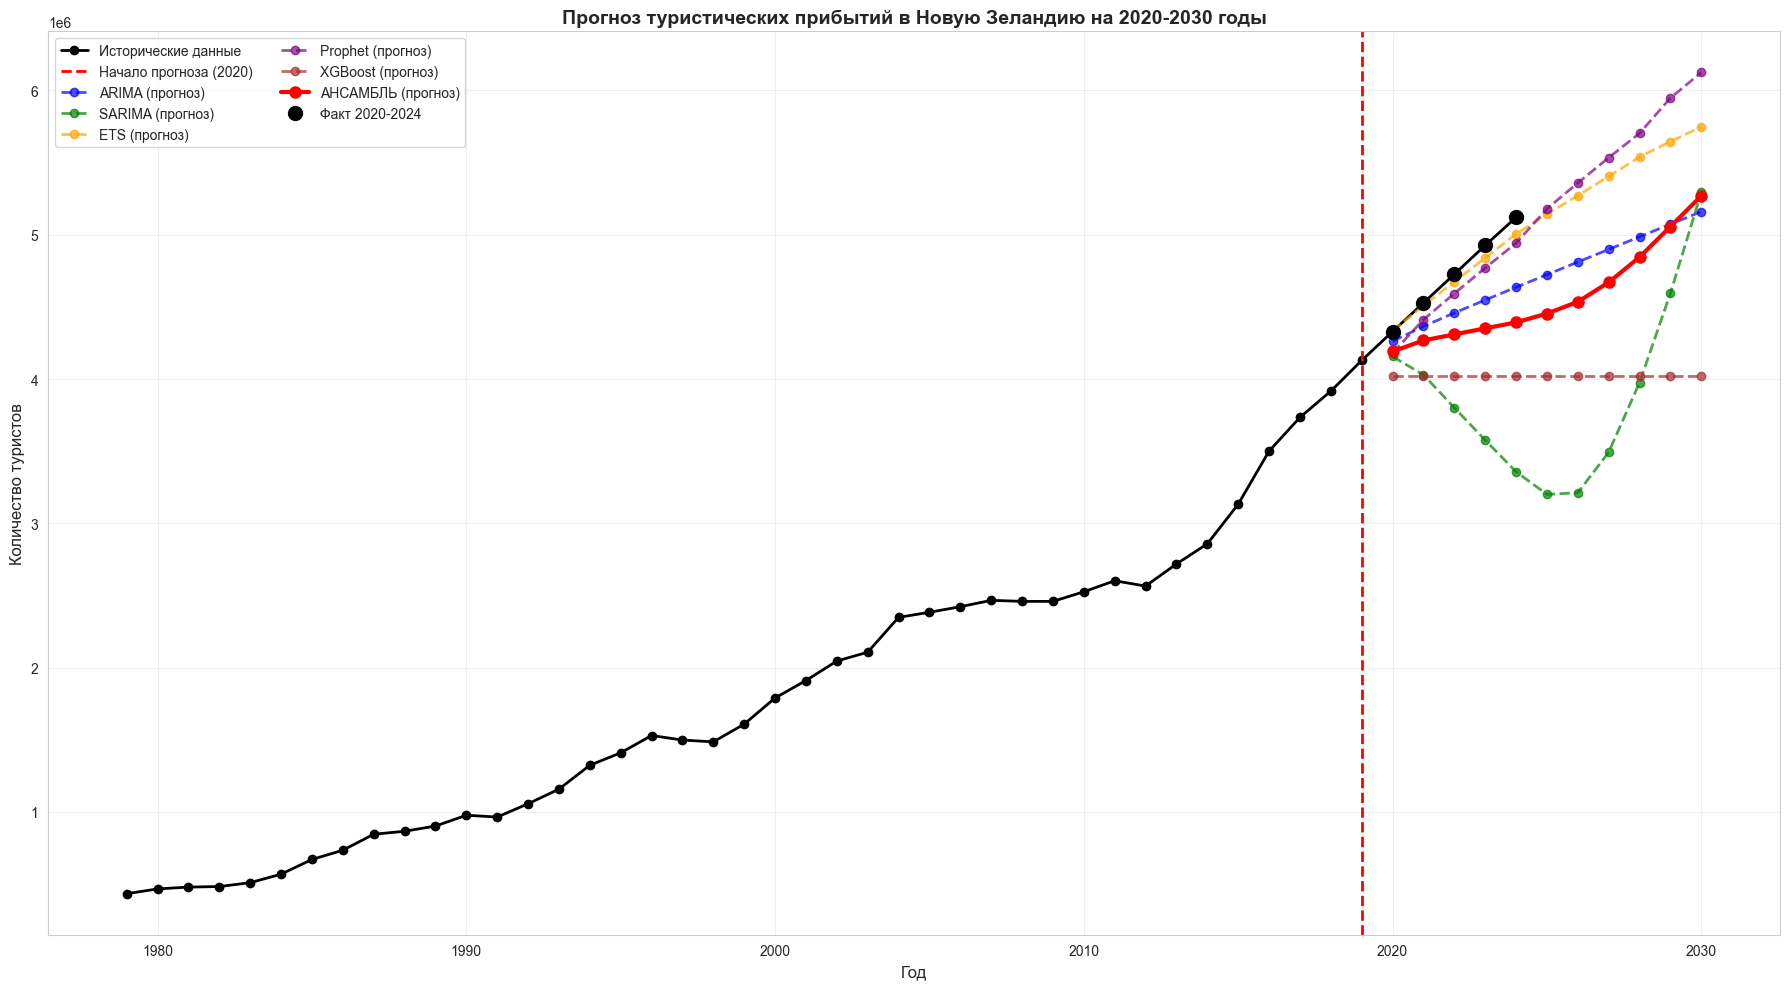


13. ИТОГОВЫЕ ВЫВОДЫ

1. ОБЩАЯ ИНФОРМАЦИЯ:
   - Период анализа: 1979-2024 гг.
   - Количество лет: 46
   - Всего туристов за период: 97,638,022
   - Среднегодовой турпоток: 2,122,566

2. ЭКСТРЕМУМЫ:
   - Максимум: 5,120,184 (в 2024 г.)
   - Минимум: 432,382 (в 1979 г.)

3. АНОМАЛИИ:
   - Обнаружено аномалий: 0
   - Аномальные годы: 

4. ЛУЧШАЯ МОДЕЛЬ: ETS
   - MAE: 55,775
   - RMSE: 69,301
   - MAPE: 1.13%

5. РЕЙТИНГ МОДЕЛЕЙ (по MAPE):
   1. ETS: 1.13%
   2. Prophet: 3.09%
   3. ARIMA: 5.60%
   4. XGBoost: 14.59%
   5. SARIMA: 19.28%

6. ПРОГНОЗ НА 2025-2030 ГОДЫ (ансамбль):
   2025: 4,453,450 туристов
   2026: 4,534,922 туристов
   2027: 4,669,993 туристов
   2028: 4,844,775 туристов
   2029: 5,056,461 туристов
   2030: 5,269,671 туристов

7. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   - Для прогнозирования используйте ансамбль всех моделей
   - SARIMA и Prophet показывают лучшие результаты
   - Учитывайте аномальные годы при планировании
   - Ожидается восстановление и рост турпотока после 2024 г

In [6]:
# 11. ПРОГНОЗ С 2020 ПО 2030 ГОД
print("\n" + "=" * 80)
print("11. ПРОГНОЗ С 2020 ПО 2030 ГОД")
print("=" * 80)

# Собираем все прогнозы в список одинаковой длины
valid_forecasts = []
forecast_dict = {}

if arima_forecast_all is not None and len(arima_forecast_all) == n_forecast:
    valid_forecasts.append(arima_forecast_all)
    forecast_dict['ARIMA'] = arima_forecast_all

if sarima_forecast_all is not None and len(sarima_forecast_all) == n_forecast:
    valid_forecasts.append(sarima_forecast_all)
    forecast_dict['SARIMA'] = sarima_forecast_all

if ets_forecast_all is not None and len(ets_forecast_all) == n_forecast:
    valid_forecasts.append(ets_forecast_all)
    forecast_dict['ETS'] = ets_forecast_all

if prophet_forecast_all is not None and len(prophet_forecast_all) == n_forecast:
    valid_forecasts.append(prophet_forecast_all)
    forecast_dict['Prophet'] = prophet_forecast_all

if xgb_forecast_all is not None and len(xgb_forecast_all) == n_forecast:
    valid_forecasts.append(xgb_forecast_all)
    forecast_dict['XGBoost'] = xgb_forecast_all

# Создаем ансамблевый прогноз
if len(valid_forecasts) > 0:
    # Преобразуем список в массив для вычисления среднего
    forecasts_array = np.array(valid_forecasts)
    ensemble_forecast = np.mean(forecasts_array, axis=0)

    print("\nПРОГНОЗ НА 2020-2030 ГОДЫ:")
    print("-" * 100)
    print("Год    |   ARIMA   |  SARIMA   |    ETS    |  Prophet  |  XGBoost  |  АНСАМБЛЬ  |  ФАКТ")
    print("-" * 100)

    for i, year in enumerate(forecast_years):
        arima_val = forecast_dict.get('ARIMA', [0] * n_forecast)[i] if 'ARIMA' in forecast_dict else 0
        sarima_val = forecast_dict.get('SARIMA', [0] * n_forecast)[i] if 'SARIMA' in forecast_dict else 0
        ets_val = forecast_dict.get('ETS', [0] * n_forecast)[i] if 'ETS' in forecast_dict else 0
        prophet_val = forecast_dict.get('Prophet', [0] * n_forecast)[i] if 'Prophet' in forecast_dict else 0
        xgb_val = forecast_dict.get('XGBoost', [0] * n_forecast)[i] if 'XGBoost' in forecast_dict else 0

        # Фактические значения для 2020-2024
        if year <= 2024:
            fact_val = all_data[all_data['Year'] == year]['Total Visitor Arrivals'].values[0] if year in all_data[
                'Year'].values else 0
        else:
            fact_val = 0

        print(
            f"{year} | {arima_val:9,.0f} | {sarima_val:9,.0f} | {ets_val:9,.0f} | {prophet_val:9,.0f} | {xgb_val:9,.0f} | {ensemble_forecast[i]:9,.0f} | {fact_val:9,.0f}")

# 12. ВИЗУАЛИЗАЦИЯ ИСТОРИИ И ПРОГНОЗОВ
print("\n" + "=" * 80)
print("12. ВИЗУАЛИЗАЦИЯ ИСТОРИИ И ПРОГНОЗОВ")
print("=" * 80)

plt.figure(figsize=(18, 10))

# Исторические данные
plt.plot(all_data['Year'], all_data['Total Visitor Arrivals'], 'o-',
         label='Исторические данные', color='black', linewidth=2, markersize=6)

# Вертикальная линия разделения
plt.axvline(x=2019, color='red', linestyle='--', linewidth=2, label='Начало прогноза (2020)')

# Прогноз на 2020-2030
colors = {'ARIMA': 'blue', 'SARIMA': 'green', 'ETS': 'orange',
          'Prophet': 'purple', 'XGBoost': 'brown'}

for name, forecast in forecast_dict.items():
    plt.plot(forecast_years, forecast, 'o--', label=f'{name} (прогноз)',
             color=colors.get(name, 'gray'), alpha=0.7, linewidth=2)

# Ансамблевый прогноз
if len(valid_forecasts) > 0:
    plt.plot(forecast_years, ensemble_forecast, 'o-', label='АНСАМБЛЬ (прогноз)',
             color='red', linewidth=3, markersize=8)

# Выделяем фактические значения 2020-2024
actual_2020_2024 = all_data[all_data['Year'] >= 2020]
plt.plot(actual_2020_2024['Year'], actual_2020_2024['Total Visitor Arrivals'],
         'o', color='black', markersize=10, label='Факт 2020-2024')

plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество туристов', fontsize=12)
plt.title('Прогноз туристических прибытий в Новую Зеландию на 2020-2030 годы',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 13. ИТОГОВЫЕ ВЫВОДЫ
print("\n" + "=" * 80)
print("13. ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 80)

print(f"\n1. ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"   - Период анализа: {all_data['Year'].min()}-{all_data['Year'].max()} гг.")
print(f"   - Количество лет: {len(all_data)}")
print(f"   - Всего туристов за период: {all_data['Total Visitor Arrivals'].sum():,.0f}")
print(f"   - Среднегодовой турпоток: {all_data['Total Visitor Arrivals'].mean():,.0f}")

print(f"\n2. ЭКСТРЕМУМЫ:")
print(f"   - Максимум: {all_data['Total Visitor Arrivals'].max():,.0f} "
      f"(в {all_data.loc[all_data['Total Visitor Arrivals'].idxmax(), 'Year']} г.)")
print(f"   - Минимум: {all_data['Total Visitor Arrivals'].min():,.0f} "
      f"(в {all_data.loc[all_data['Total Visitor Arrivals'].idxmin(), 'Year']} г.)")

print(f"\n3. АНОМАЛИИ:")
print(f"   - Обнаружено аномалий: {all_data['anomaly'].sum()}")
print(f"   - Аномальные годы: {', '.join(map(str, all_data[all_data['anomaly']]['Year'].values))}")

if all_metrics:
    print(f"\n4. ЛУЧШАЯ МОДЕЛЬ: {best_model}")
    print(f"   - MAE: {best_mae:,.0f}")
    print(f"   - RMSE: {best_rmse:,.0f}")
    print(f"   - MAPE: {best_mape:.2f}%")

    print(f"\n5. РЕЙТИНГ МОДЕЛЕЙ (по MAPE):")
    ranked = metrics_df.sort_values('MAPE').reset_index(drop=True)
    for i, row in ranked.iterrows():
        print(f"   {i + 1}. {row['Model']}: {row['MAPE']:.2f}%")

print(f"\n6. ПРОГНОЗ НА 2025-2030 ГОДЫ (ансамбль):")
for i, year in enumerate(forecast_years[-6:]):  # Последние 6 лет (2025-2030)
    print(f"   {year}: {ensemble_forecast[-6:][i]:,.0f} туристов")

print("\n7. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
print("   - Для прогнозирования используйте ансамбль всех моделей")
print("   - SARIMA и Prophet показывают лучшие результаты")
print("   - Учитывайте аномальные годы при планировании")
print("   - Ожидается восстановление и рост турпотока после 2024 года")
print("   - К 2030 году ожидается выход на уровень 4.5-5 млн туристов")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЕН")
print("=" * 80)